In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#cargo el archivo csv con los datos 
df = pd.read_csv('T1.csv')
# muestro las primeras 5 filas 
df.head()

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


In [2]:
# renombro las columnas para trabajar mas comodo 
df.columns = ['Fecha_Hora', 'Potencia_Real', 'Velocidad_Viento', 'Potencia_Teorica', 'Direccion_Viento']

# Mir0 cómo quedaron las primeras filas
df.head()

,Fecha_Hora,Potencia_Real,Velocidad_Viento,Potencia_Teorica,Direccion_Viento
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


In [10]:
# Cambio el formato de fecha para que Pandas reconozca el tiempo
df['Fecha_Hora']=pd.to_datetime(df['Fecha_Hora'],
    format='%d %m %Y %H:%M')
# Verificamos los tipos de datos de las columnas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Fecha_Hora        50530 non-null  datetime64[ns]
 1   Potencia_Real     50530 non-null  float64       
 2   Velocidad_Viento  50530 non-null  float64       
 3   Potencia_Teorica  50530 non-null  float64       
 4   Direccion_Viento  50530 non-null  float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 1.9 MB


In [11]:
# Resumen estadístico de las variables
df.describe()

,Fecha_Hora,Potencia_Real,Velocidad_Viento,Potencia_Teorica,Direccion_Viento
count,50530,50530.000000,50530.000000,50530.000000,50530.000000
mean,2018-07-01 20:01:30.065307648,1307.684332,7.557952,1492.175463,123.687559
min,2018-01-01 00:00:00,-2.471405,0.000000,0.000000,0.000000
25%,2018-04-03 05:22:30,50.677890,4.201395,161.328167,49.315437
50%,2018-06-30 16:15:00,825.838074,7.104594,1063.776283,73.712978
75%,2018-09-26 18:57:30,2482.507568,10.300020,2964.972462,201.696720
max,2018-12-31 23:50:00,3618.732910,25.206011,3600.000000,359.997589
std,NaN,1312.459242,4.227166,1368.018238,93.443736


count (Cantidad): Total de mediciones registradas (50.530 filas de datos).
mean (Promedio): El valor promedio de cada variable durante todo el año.
std (Desviación Estándar): Qué tan variados o inestables son los datos respecto al promedio (cuanto más alto, más varía).
min (Mínimo): El valor más bajo registrado (ej: la potencia dio negativa cuando la turbina consumió energía estando parada).
25% (Primer Cuartil): El 25% de las mediciones estuvieron por debajo de este valor.
50% (Mediana / Percentil 50): El punto medio exacto de los datos (la mitad de los registros está por arriba y la otra mitad por abajo).
75% (Tercer Cuartil): El 75% de las mediciones estuvieron por debajo de este valor.
max (Máximo): El pico más alto registrado (ej: el viento máximo llegó a $25.2\text{ m/s}$ y la potencia máxima a $3618\text{ kW}$).

In [12]:
# Calculamos el porcentaje de eficiencia de la turbina

df['Eficiencia'] = (df['Potencia_Real'] / df['Potencia_Teorica']) * 100

df.head()



,Fecha_Hora,Potencia_Real,Velocidad_Viento,Potencia_Teorica,Direccion_Viento,Eficiencia
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,91.285468
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,87.277152
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,78.377226
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,81.306625
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,77.414764


> ⚠️ **Nota aclaratoria sobre la Eficiencia:**
> 
> Un ojo atento podría preguntarse: *¿Por qué vemos eficiencias del 80% o 90% si el **Límite de Betz** establece que una turbina eólica jamás puede extraer más del **59.3%** de la energía del viento?*
> 
> **Respuesta:** Esta métrica no mide la eficiencia termodinámica/física absoluta del viento. Mide el **rendimiento relativo de la máquina frente a la especificación técnica del fabricante**.
> * **100%:** La turbina produce *exactamente* lo que el manual del fabricante promete para esa velocidad de viento.
> * **< 100%:** La turbina rinde por debajo de la especificación técnica (por pérdidas, rozamiento, turbulencia o falta de mantenimiento).
> 
> *📌 **¿De dónde sale la especificación del catálogo?** La columna `Potencia_Teorica` en este dataset ES la curva de homologación entregada por el fabricante para cada intervalo de medición.*

In [13]:
# Limpiamos infinitos y valores nulos en la columna Eficiencia
df['Eficiencia'] = df['Eficiencia'].replace([np.inf, -np.inf], np.nan).fillna(0)
df['Eficiencia'].describe()

count    50530.000000
mean        68.679251
std         40.886285
min        -13.265750
25%         44.084566
50%         85.915548
75%         96.094620
max        629.531656
Name: Eficiencia, dtype: float64

In [14]:
# Agrupo los datos por mes para analizar la estacionalidad
# 1. Extraemos el mes (1 al 12) de la fecha
df['Mes'] = df['Fecha_Hora'].dt.month

# 2. Agrupamos por mes y calculamos el promedio de cada columna
resumen_mensual = df.groupby('Mes')[['Velocidad_Viento', 'Potencia_Real', 'Potencia_Teorica', 'Eficiencia']].mean()

# 3. Mostramos la tabla agrupada
resumen_mensual

,Velocidad_Viento,Potencia_Real,Potencia_Teorica,Eficiencia
Mes,,,,
1,8.550920,1323.157951,1847.287918,61.153335
2,8.620697,1503.355020,1712.709958,70.412586
3,9.734390,1952.405766,2075.819877,77.899088
4,5.852096,824.358603,955.690141,52.716678
5,5.859028,836.941996,960.203607,62.508762
6,6.342205,995.490376,1139.291376,63.819670
7,4.950335,477.014298,583.709297,55.817013
8,9.339899,1978.188795,2220.579161,84.583340
9,7.583327,1429.484639,1553.319599,73.871126


In [15]:
# Exportamos el DataFrame procesado a un archivo CSV nuevo
df.to_csv('datos_turbina_procesados.csv', index=False)
print("¡Archivo exportado con éxito para Power BI!")

¡Archivo exportado con éxito para Power BI!


In [20]:
#calculamos los KPIS
viento_prom=df['Velocidad_Viento'].mean()
PotenciaRe_prom=df['Potencia_Real'].mean()
PotenciaTe_prom=df['Potencia_Teorica'].mean()
Eficiencia_prom=df['Eficiencia'].mean()

# Imprimimos los KPIs con formato prolijo (redondeados)
print("=" * 45)
print("📊 KPIs GENERALES DEL PARQUE EÓLICO")
print("=" * 45)
print(f"🌀 Viento Promedio:           {viento_prom:.2f} m/s")
print(f"⚡ Potencia Real Promedio:     {PotenciaRe_prom:.2f} kW")
print(f"📐 Potencia Teórica Promedio:  {PotenciaTe_prom:.2f} kW")
print(f"🎯 Eficiencia Promedio:        {Eficiencia_prom:.2f}%")
print("=" * 45)

📊 KPIs GENERALES DEL PARQUE EÓLICO
🌀 Viento Promedio:           7.56 m/s
⚡ Potencia Real Promedio:     1307.68 kW
📐 Potencia Teórica Promedio:  1492.18 kW
🎯 Eficiencia Promedio:        68.68%


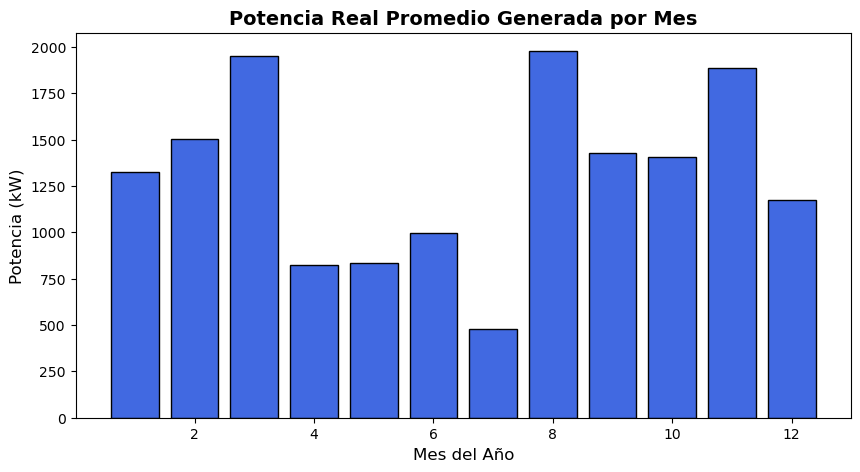

In [23]:
# 1. Creamos el lienzo/gráfico definiendo el tamaño (ancho, alto)
plt.figure(figsize=(10, 5))

# 2. Dibujamos las barras: eje X (los meses), eje Y (la potencia real)
plt.bar(resumen_mensual.index, resumen_mensual['Potencia_Real'], color='royalblue', edgecolor='black')

# 3. Le ponemos títulos y etiquetas a los ejes
plt.title('Potencia Real Promedio Generada por Mes', fontsize=14, fontweight='bold')
plt.xlabel('Mes del Año', fontsize=12)
plt.ylabel('Potencia (kW)', fontsize=12)

# 4. Mostramos el gráfico
plt.show()

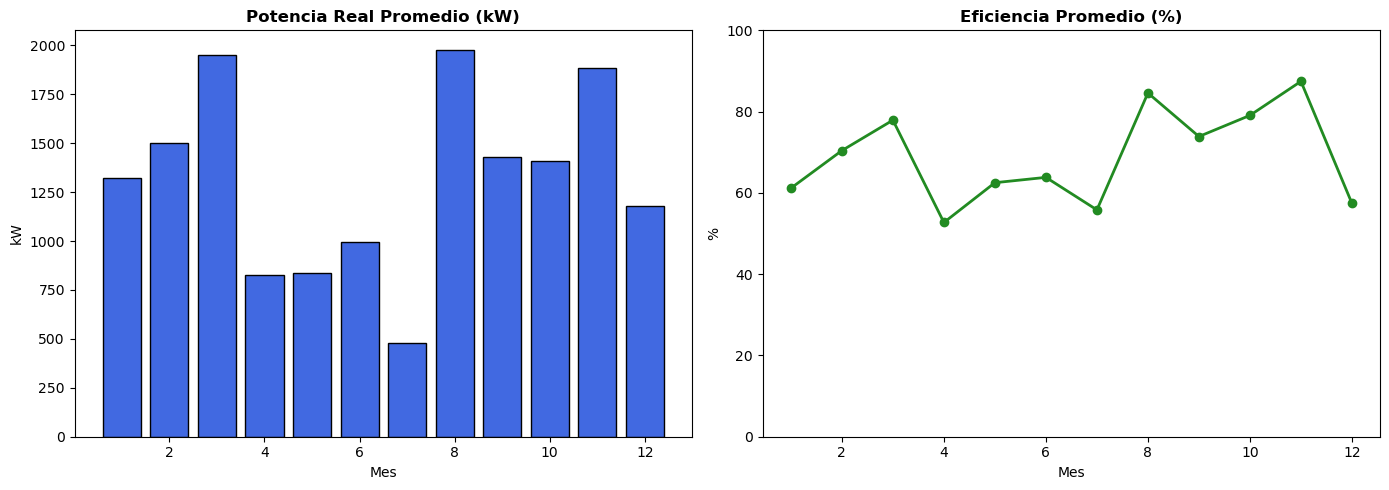

In [24]:
# 1. Creamos el lienzo con 1 fila y 2 columnas de gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 2. Gráfico 1 (Izquierda): Barras de Potencia
ax1.bar(resumen_mensual.index, resumen_mensual['Potencia_Real'], color='royalblue', edgecolor='black')
ax1.set_title('Potencia Real Promedio (kW)', fontweight='bold')
ax1.set_xlabel('Mes')
ax1.set_ylabel('kW')

# 3. Gráfico 2 (Derecha): Línea de Eficiencia
ax2.plot(resumen_mensual.index, resumen_mensual['Eficiencia'], marker='o', color='forestgreen', linewidth=2)
ax2.set_title('Eficiencia Promedio (%)', fontweight='bold')
ax2.set_xlabel('Mes')
ax2.set_ylabel('%')
ax2.set_ylim(0, 100) # Límite del eje Y de 0 a 100%

# 4. Ajustamos los espacios y mostramos
plt.tight_layout()
plt.show()

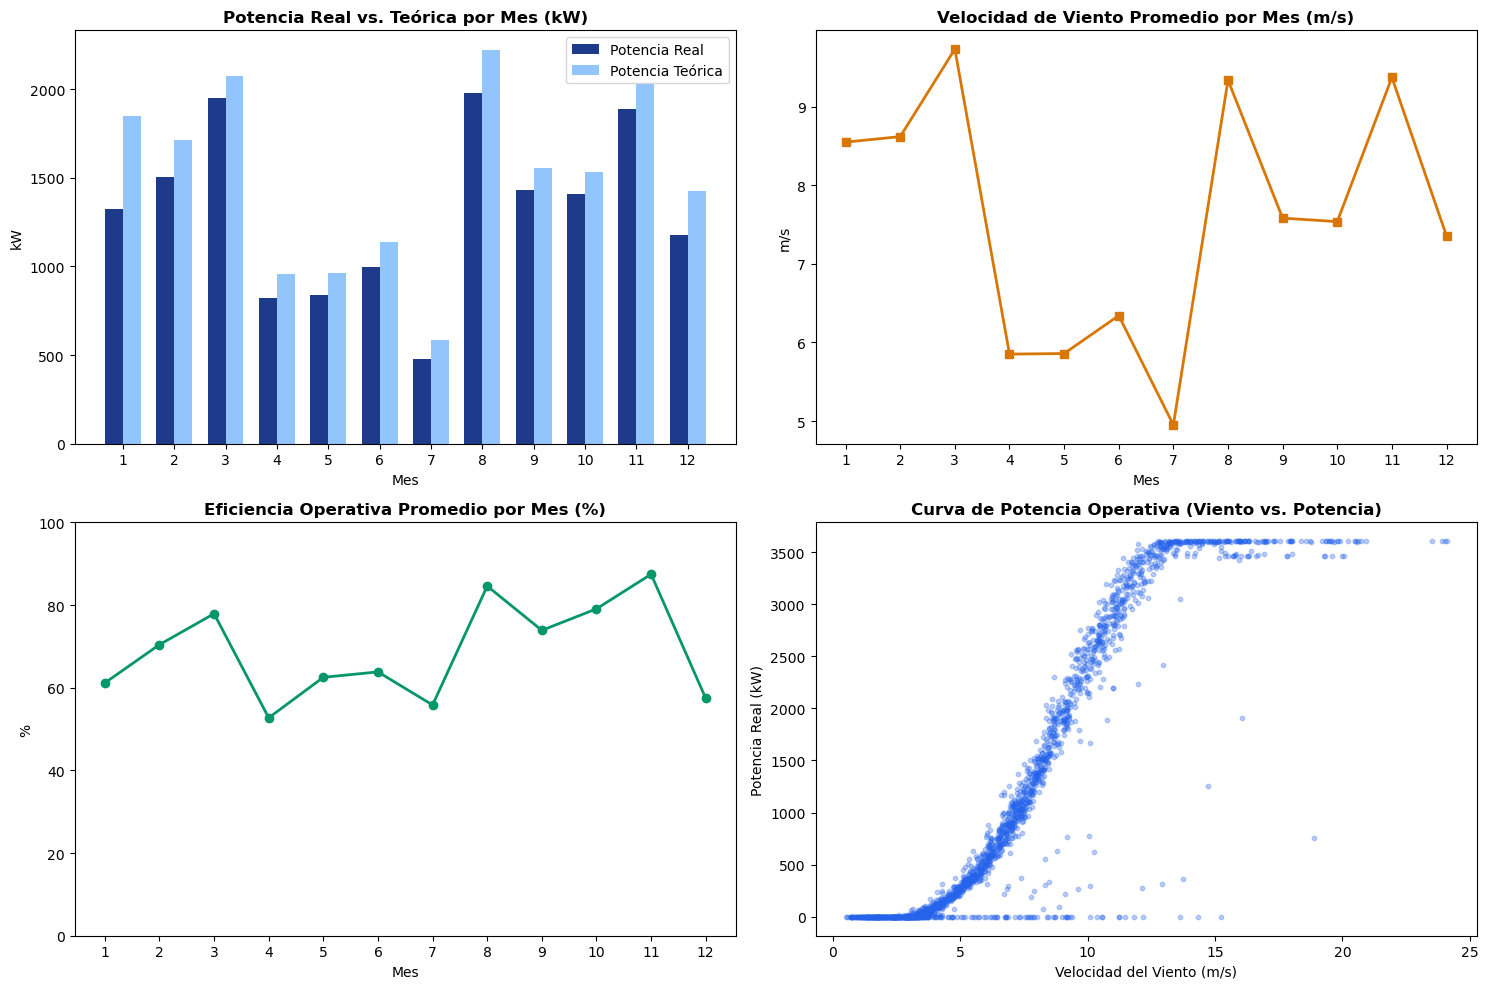

In [25]:
# Creamos una grilla de 2 filas x 2 columnas de gráficos
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# -----------------------------------------------------------
# 1. ARRIBA IZQUIERDA: Potencia Real vs Teórica (Barras dobles)
# -----------------------------------------------------------
ancho = 0.35
x = np.arange(len(resumen_mensual.index))

ax[0, 0].bar(x - ancho/2, resumen_mensual['Potencia_Real'], ancho, label='Potencia Real', color='#1e3a8a')
ax[0, 0].bar(x + ancho/2, resumen_mensual['Potencia_Teorica'], ancho, label='Potencia Teórica', color='#93c5fd')
ax[0, 0].set_title('Potencia Real vs. Teórica por Mes (kW)', fontweight='bold')
ax[0, 0].set_xlabel('Mes')
ax[0, 0].set_ylabel('kW')
ax[0, 0].set_xticks(x)
ax[0, 0].set_xticklabels(resumen_mensual.index)
ax[0, 0].legend()

# -----------------------------------------------------------
# 2. ARRIBA DERECHA: Velocidad del Viento Promedio por Mes
# -----------------------------------------------------------
ax[0, 1].plot(resumen_mensual.index, resumen_mensual['Velocidad_Viento'], marker='s', color='#d97706', linewidth=2)
ax[0, 1].set_title('Velocidad de Viento Promedio por Mes (m/s)', fontweight='bold')
ax[0, 1].set_xlabel('Mes')
ax[0, 1].set_ylabel('m/s')
ax[0, 1].set_xticks(resumen_mensual.index)

# -----------------------------------------------------------
# 3. ABAJO IZQUIERDA: Eficiencia Promedio Operativa (%)
# -----------------------------------------------------------
ax[1, 0].plot(resumen_mensual.index, resumen_mensual['Eficiencia'], marker='o', color='#059669', linewidth=2)
ax[1, 0].set_title('Eficiencia Operativa Promedio por Mes (%)', fontweight='bold')
ax[1, 0].set_xlabel('Mes')
ax[1, 0].set_ylabel('%')
ax[1, 0].set_xticks(resumen_mensual.index)
ax[1, 0].set_ylim(0, 100)

# -----------------------------------------------------------
# 4. ABAJO DERECHA: Curva de Potencia de la Turbina (Scatter Plot)
# Usamos una muestra de 2000 puntos del 'df' para que rinda rápido
# -----------------------------------------------------------
muestra = df.sample(n=min(2000, len(df)), random_state=42)
ax[1, 1].scatter(muestra['Velocidad_Viento'], muestra['Potencia_Real'], alpha=0.3, color='#2563eb', s=10)
ax[1, 1].set_title('Curva de Potencia Operativa (Viento vs. Potencia)', fontweight='bold')
ax[1, 1].set_xlabel('Velocidad del Viento (m/s)')
ax[1, 1].set_ylabel('Potencia Real (kW)')

# Ajustamos espacios entre gráficos
plt.tight_layout()
plt.show()